In [8]:
import json
import pandas as pd
import nltk
import re
import string
import unicodedata
from pathlib import Path
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gusta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gusta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gusta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
stop_words = set(stopwords.words("english"))

In [10]:
BASE_DIR = Path.cwd().parent
DATA_FULL = BASE_DIR / "clinc150" / "clinc150_uci" / "data_full.json"
DF_TRAIN = BASE_DIR / "dataset"/ "processed"/ "train.csv"
DF_VAL = BASE_DIR / "dataset"/ "processed"/ "val.csv"
DF_TEST = BASE_DIR / "dataset"/ "processed"/ "test.csv"
DFRAW = BASE_DIR / "dataset"/ "raw"/ "dataRaw.csv"

with open(DATA_FULL,
          "r", encoding="utf-8") as f:
    dados = json.load(f)

df_train = pd.DataFrame(dados["train"], columns=["text", "intent"])
df_val = pd.DataFrame(dados["val"], columns=["text", "intent"])
df_test = pd.DataFrame(dados["test"], columns=["text", "intent"])

#send to appropriate folder (./processed)
df_train.to_csv(DF_TRAIN, index=False, sep=";")
df_val.to_csv(DF_VAL, index=False, sep=";")
df_test.to_csv(DF_TEST, index=False, sep=";")

In [11]:
DFRAW

WindowsPath('c:/Users/gusta/Desktop/chatBot/intencaoChatBot/dataset/raw/dataRaw.csv')

In [12]:
dfRaw = []
dfRaw.extend([df_train, df_val, df_test])
dfRaw = pd.concat(dfRaw, ignore_index=True)
#send to appropriate folder (./raw)
dfRaw.to_csv(DFRAW, index=False)

In [13]:
dfRaw

,text,intent
0,what expression would i use to say i love you ...,translate
1,can you tell me how to say 'i do not speak muc...,translate
2,"what is the equivalent of, 'life is good' in f...",translate
3,"tell me how to say, 'it is a beautiful morning...",translate
4,"if i were mongolian, how would i say that i am...",translate
...,...,...
22495,why can't i use my credit card,card_declined
22496,why won't you let me pay with my credit card,card_declined
22497,why did i get rejected on my card,card_declined
22498,how come my credit card isn't working,card_declined


In [14]:
dfRaw.groupby(['intent'])['intent'].count().sort_values(ascending=False).head(10)

intent
accept_reservations    150
account_blocked        150
alarm                  150
application_status     150
apr                    150
are_you_a_bot          150
balance                150
bill_balance           150
bill_due               150
book_flight            150
Name: intent, dtype: int64

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1, 1))
vectorizer.fit(dfRaw.text)
text_vector = vectorizer.transform(dfRaw.text)

pd.DataFrame(text_vector.toarray(), columns=vectorizer.get_feature_names_out())

,00,000,005,00am,00pm,01,02,03,05,098098,...,zimbabwe,zion,zippy,zippys,ziti,zombie,zone,zones,zoo,zulu
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
22498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 1), use_idf=True)
vectorizer.fit(dfRaw.text)
text_vector = vectorizer.transform(dfRaw.text)


pd.DataFrame(text_vector.toarray(), columns=vectorizer.get_feature_names_out())

,00,000,005,00am,00pm,01,02,03,05,098098,...,zimbabwe,zion,zippy,zippys,ziti,zombie,zone,zones,zoo,zulu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22495,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
22498,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
def normalize_accents(text):
    return unicodedata.normalize("NFKD", text).encode("ASCII", "ignore").decode("utf-8")

In [18]:
def remove_punctuation(text):
    punctuations = string.punctuation
    table = str.maketrans({key: " " for key in punctuations})
    text = text.translate(table)
    return text

In [19]:
def normalize_str(text):
    text = text.lower()
    text = remove_punctuation(text)
    text = normalize_accents(text)
    text = re.sub(re.compile(r" +"), " ",text)
    return " ".join([w for w in text.split()])

In [20]:
def tokenizeFunc(text):
    stop_words = nltk.corpus.stopwords.words("english") # portuguese, caso o dataset seja em português
    if isinstance(text, str):
        text = normalize_str(text)
        text = "".join([w for w in text if not w.isdigit()])
        text = word_tokenize(text)
        text = [x for x in text if x not in stop_words]
        text = [y for y in text if len(y) > 2]
        return " ".join([t for t in text])
    else:
        return None

In [21]:
tokenizeFunc("Exemplo$ de 12 normalização!!")

'exemplo normalizacao'

In [22]:
df_train["text_treated"] = df_train["text"].apply(tokenizeFunc)
df_val["text_treated"] = df_val["text"].apply(tokenizeFunc)
df_test["text_treated"] = df_test["text"].apply(tokenizeFunc)

In [ ]:
tokenizer = Tokenizer()  
tokenizer.fit_on_texts(df_train["text_treated"])
X_train = tokenizer.texts_to_sequences(df_train["text_treated"])
X_val = tokenizer.texts_to_sequences(df_val["text_treated"])
X_test = tokenizer.texts_to_sequences(df_test["text_treated"])

import pickle

with open(r"\models\tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)



In [149]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(df_train["intent"])
y_val = encoder.transform(df_val["intent"])
y_test = encoder.transform(df_test["intent"])

with open(r".\models\label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [150]:
from keras.preprocessing.sequence import pad_sequences

X_train = pad_sequences(
    X_train,
    maxlen=20,
    padding="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=20,
    padding="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=20,
    padding="post"
)

In [162]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=128,
        input_length=30
    ),

    Bidirectional(
        LSTM(128)
    ),
    Dropout(0.2),
    
    Dense(150, activation="softmax")
])

In [23]:
# Defina um objeto ModelCheckpoint para usar os melhores pesos para este modelo
checkpointer = ModelCheckpoint(filepath="./models/weights.best.keras", verbose=0, save_best_only=True) # save best model
learning_rate = 0.001

In [164]:
# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=5, verbose=1, mode='auto', restore_best_weights=True) #Aqui utilizando early stopping

# Compilando o modelo e aplicação a função de custo Adam (utilizando a learning rate que configuramos anteriormente)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Resumo do modelo
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [165]:
print(y_train.shape)
print(y_train[0])

(15000,)
131


In [166]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    validation_split=0.25,
                    verbose=1,callbacks=[monitor, checkpointer], epochs=45, batch_size=50, shuffle=True
)

# Salve os dados do modelo em um arquivo h5 
model.save('./models/feelings.keras')

Epoch 1/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.2641 - loss: 3.7208 - val_accuracy: 0.6480 - val_loss: 1.8024
Epoch 2/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.7931 - loss: 0.9661 - val_accuracy: 0.7860 - val_loss: 0.8911
Epoch 3/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8951 - loss: 0.4543 - val_accuracy: 0.8220 - val_loss: 0.7256
Epoch 4/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9331 - loss: 0.2832 - val_accuracy: 0.8200 - val_loss: 0.6972
Epoch 5/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9505 - loss: 0.2096 - val_accuracy: 0.8333 - val_loss: 0.6917
Epoch 6/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9597 - loss: 0.1623 - val_accuracy: 0.8343 - val_loss: 0.6868
Epoch 7/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.9649 - loss: 0.1354 - val_accuracy: 0.8340 - val_loss: 0.6905
Epoch 8/45
300/300 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.9690 - loss: 0.1152 - 

In [167]:
loss, acc = model.evaluate(
    X_test,
    y_test
)

print(acc)

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8380 - loss: 0.6477
0.8379999995231628


In [168]:
loss, acc = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc:.4f}")

141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8380 - loss: 0.6477
Test Loss: 0.6477
Test Accuracy: 0.8380


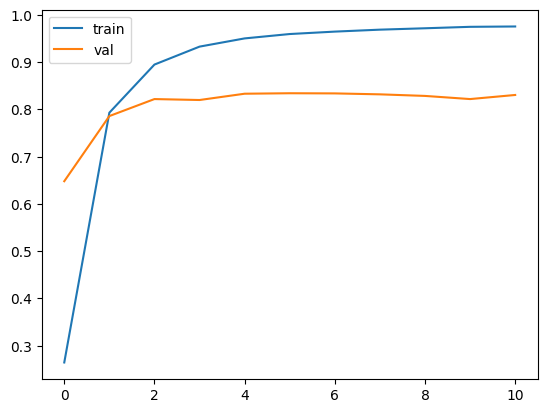

In [169]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.show()

In [170]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.2641333341598511, 0.7931333184242249, 0.8950666785240173, 0.9330666661262512, 0.9504666924476624, 0.9597333073616028, 0.9648666381835938, 0.968999981880188, 0.9719333052635193, 0.9750000238418579, 0.9757333397865295]
[0.6480000019073486, 0.7860000133514404, 0.8220000267028809, 0.8199999928474426, 0.8333333134651184, 0.8343333601951599, 0.8339999914169312, 0.8320000171661377, 0.8286666870117188, 0.8220000267028809, 0.8306666612625122]


In [171]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_true = y_test
y_pred = np.argmax(model.predict(X_test), axis=1)

report = classification_report(y_true, y_pred, target_names=encoder.classes_,output_dict=True, 
    digits=3)

print(report)

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
{'accept_reservations': {'precision': 0.8125, 'recall': 0.8666666666666667, 'f1-score': 0.8387096774193549, 'support': 30.0}, 'account_blocked': {'precision': 0.7058823529411765, 'recall': 0.8, 'f1-score': 0.75, 'support': 30.0}, 'alarm': {'precision': 0.8571428571428571, 'recall': 1.0, 'f1-score': 0.9230769230769231, 'support': 30.0}, 'application_status': {'precision': 0.9666666666666667, 'recall': 0.9666666666666667, 'f1-score': 0.9666666666666667, 'support': 30.0}, 'apr': {'precision': 0.8571428571428571, 'recall': 1.0, 'f1-score': 0.9230769230769231, 'support': 30.0}, 'are_you_a_bot': {'precision': 1.0, 'recall': 0.9666666666666667, 'f1-score': 0.9830508474576272, 'support': 30.0}, 'balance': {'precision': 0.8333333333333334, 'recall': 0.8333333333333334, 'f1-score': 0.8333333333333334, 'support': 30.0}, 'bill_balance': {'precision': 0.9047619047619048, 'recall': 0.6333333333333333, 'f1-score': 0.74

In [172]:
df_report = pd.DataFrame(report).transpose()

df_report

,precision,recall,f1-score,support
accept_reservations,0.812500,0.866667,0.838710,30.000
account_blocked,0.705882,0.800000,0.750000,30.000
alarm,0.857143,1.000000,0.923077,30.000
application_status,0.966667,0.966667,0.966667,30.000
apr,0.857143,1.000000,0.923077,30.000
...,...,...,...,...
who_made_you,0.774194,0.800000,0.786885,30.000
yes,0.750000,0.500000,0.600000,30.000
accuracy,0.838000,0.838000,0.838000,0.838
macro avg,0.851487,0.838000,0.837734,4500.000


In [173]:
df_report.sort_values("f1-score", inplace=True)

In [174]:
df_report.to_excel("./classification_report.xlsx", index=True)